# Laboratório — BFS, DFS e UCS

Neste laboratório o código está completo. A sua tarefa é **executar, alterar parâmetros, observar e responder a cinco questões**. Não precisa de escrever funções.

## Como trabalhar
1. Abra no Google Colab e guarde uma cópia no Drive. Não é necessária GPU.
2. Execute as células pela ordem apresentada. Python, pandas e matplotlib estão disponíveis no Colab.
3. Altere apenas os parâmetros marcados **ALTERAR** e repita a célula.
4. Preencha as células **Resposta** com valores e explicações. O histórico conserva as execuções durante a sessão.
5. Entregue com respostas e resultados guardados. Reiniciar a sessão ou executar novamente a preparação limpa o histórico.

## O que vamos comparar?
- **BFS:** fila FIFO; retira o primeiro estado descoberto que ainda aguarda processamento.
- **DFS:** pilha LIFO; retira o estado no topo. Para explorar os sucessores por ordem alfabética, insere-os na pilha pela ordem inversa.
- **UCS:** fila de prioridade; retira o estado com menor custo acumulado `g`. Em empate, usa FIFO.

Usamos **pesquisa em grafo**. BFS e DFS ignoram estados que já estejam em OPEN ou VISITED e conservam o primeiro pai. UCS atualiza o custo e o pai de um estado em OPEN quando encontra um caminho estritamente melhor. Como os custos são positivos, um estado retirado por UCS já tem custo ótimo; não é necessário reabri-lo.

**OPEN** contém os estados que aguardam processamento. Nas tabelas, o próximo a retirar está sempre **à esquerda**: frente da fila, topo da pilha ou menor prioridade. Cada entrada mostra `estado:g`; apenas UCS usa esse custo como prioridade.

**VISITED** regista todos os estados retirados, incluindo objetivos. **Expansão** significa gerar sucessores; um objetivo é testado ao retirar e não é expandido neste laboratório. Por isso, retiradas e expansões podem ter contagens diferentes. Os três objetivos deste grafo são terminais, sem sucessores.

O grafo é **dirigido**: as setas indicam os movimentos permitidos. Os sucessores seguem ordem alfabética, salvo indicação contrária. A ordem das coordenadas do desenho não determina a ordem de geração.


In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

historico = []

def criar_grafo(custo_ag1=9):
    assert isinstance(custo_ag1,(int,float)) and math.isfinite(custo_ag1) and custo_ag1>0
    return {"S":{"A":5,"B":9,"D":6},"A":{"B":3,"G1":custo_ag1},
            "B":{"A":2,"C":1},"D":{"S":1,"C":2,"E":2},
            "C":{"S":6,"G2":5,"F":7},"E":{"G3":7},
            "F":{"D":2,"G3":8},"G1":{},"G2":{},"G3":{}}


def pesquisar(grafo, algoritmo="BFS", ordem="alfabetica", todos=False,
              atualizar_open=True, inicio="S", objetivos=("G1","G2","G3")):
    assert algoritmo in ("BFS","DFS","UCS")
    assert ordem in ("alfabetica","inversa")
    assert all(v in grafo and math.isfinite(c) and c>0 for adj in grafo.values() for v,c in adj.items())
    alvos=set(objetivos); assert alvos and alvos <= set(grafo)
    assert all(not grafo[v] for v in alvos), "Nesta atividade os objetivos são terminais."
    aberto={inicio:0};g={inicio:0};pais={inicio:None};visitados=[];contador=1
    passos=[];eventos=[];encontrados=[];expansoes=0;max_open=1
    def chave(v):
        return (g[v],aberto[v]) if algoritmo=="UCS" else (-aberto[v] if algoritmo=="DFS" else aberto[v])
    def registar(acao):
        fila=sorted(aberto,key=chave)
        passos.append({"Operação":acao,"OPEN (próximo à esquerda)":str([(v,g[v]) for v in fila]),
                       "VISITED":str(visitados)})
    def caminho(v):
        p=[]
        while v is not None: p.append(v);v=pais[v]
        return list(reversed(p))
    registar("Inicial")
    while aberto:
        u=min(aberto,key=chave);del aberto[u];visitados.append(u)
        if u in alvos:
            p=caminho(u)
            encontrados.append({"Objetivo":u,"Caminho":" → ".join(p),"Custo":g[u],
                                "Profundidade":len(p)-1,"Retirada nº":len(visitados)})
            registar(f"Retirar {u}: objetivo")
            if not todos or len(encontrados)==len(alvos):break
            continue
        expansoes+=1
        sucessores=sorted(grafo[u],reverse=ordem=="inversa")
        if algoritmo=="DFS":sucessores.reverse() # empilhar na ordem inversa à exploração pretendida
        for v in sucessores:
            candidato=g[u]+grafo[u][v]
            if v in visitados:
                eventos.append({"De":u,"Para":v,"Decisão":"Ignorar: VISITED"});continue
            if v in aberto:
                if algoritmo=="UCS" and candidato<g[v]:
                    eventos.append({"De":u,"Para":v,"Decisão":
                        f"{'Atualizar' if atualizar_open else 'Ignorar melhoria'}: {g[v]} → {candidato}"})
                    if atualizar_open:g[v]=candidato;pais[v]=u
                else:eventos.append({"De":u,"Para":v,"Decisão":"Ignorar: já em OPEN, sem atualização"})
                continue
            aberto[v]=contador;contador+=1;g[v]=candidato;pais[v]=u
        max_open=max(max_open,len(aberto));registar(f"Expandir {u}")
    return dict(objetivos=encontrados,retiradas=visitados,expansoes=expansoes,
                max_open=max_open,passos=passos,eventos=eventos)


def comparar(etapa,grafo,algoritmos=("BFS","DFS","UCS"),ordem="alfabetica",
             todos=False,atualizar_open=True,detalhes=False,parametros="",objetivos=("G1","G2","G3")):
    resultados={};linhas=[]
    for algoritmo in algoritmos:
        r=pesquisar(grafo,algoritmo,ordem,todos,atualizar_open,objetivos=objetivos)
        resultados[algoritmo]=r
        linha={"Experiência":etapa,"Parâmetros":parametros,"Algoritmo":algoritmo,
               "Objetivos retirados":" → ".join(x["Objetivo"] for x in r["objetivos"]),
               "Custos":str([x["Custo"] for x in r["objetivos"]]),
               "Retiradas":len(r["retiradas"]),"Expansões":r["expansoes"],"Máximo OPEN":r["max_open"]}
        linhas.append(linha);historico.append(linha.copy())
        print("\n"+algoritmo+" — ordem de retirada:",r["retiradas"])
        display(pd.DataFrame(r["objetivos"]))
        if detalhes:
            display(pd.DataFrame(r["passos"]))
            if r["eventos"]:display(pd.DataFrame(r["eventos"]))
    display(pd.DataFrame(linhas).drop(columns=["Experiência","Parâmetros"]))
    return resultados


def desenhar(grafo):
    pos={"S":(2,3),"A":(0,2),"B":(1,1.5),"C":(2,1),"D":(3.5,2),
         "E":(5,1.2),"F":(3.5,0),"G1":(0,0.5),"G2":(1,-.3),"G3":(5,-.3)}
    fig,ax=plt.subplots(figsize=(11,6))
    for u in grafo:
        for v,c in grafo[u].items():
            x,y=pos[u];xx,yy=pos[v];curva=.18 if u in grafo[v] else 0
            ax.annotate("",xy=(xx,yy),xytext=(x,y),arrowprops=dict(arrowstyle="-|>",
                        color="#173b60",shrinkA=22,shrinkB=22,connectionstyle=f"arc3,rad={curva}"),zorder=1)
            # Nas ligações recíprocas, separar os rótulos dos dois sentidos.
            ax.text((x+xx)/2+curva*(yy-y),(y+yy)/2-curva*(xx-x),str(c),
                    bbox=dict(facecolor="white",edgecolor="none",pad=1),ha="center")
    for v,(x,y) in pos.items():
        ax.scatter(x,y,s=1300,color="#d9eddd" if v.startswith("G") else "#def0fa",edgecolor="#173b60",zorder=2)
        ax.text(x,y,v,ha="center",va="center",weight="bold",zorder=3)
    ax.set(xlim=(-.5,5.5),ylim=(-.8,3.5),title="Grafo dirigido — início S; objetivos G1, G2 e G3")
    ax.axis("off");plt.show()

print("Preparação concluída. Histórico reiniciado.")


Preparação concluída. Histórico reiniciado.


## Experiência 1 — Fila, pilha e prioridade
Execute com `ALGORITMO` igual a **"BFS", "DFS" e "UCS"**, um de cada vez. A pesquisa termina ao retirar o primeiro objetivo.

**Questão 1.** Compare objetivo, caminho, custo e profundidade. Use as tabelas para explicar qual o próximo estado escolhido em cada algoritmo. Indique um estado ignorado por já estar em OPEN e outro por já estar em VISITED. Por que razão a ordem de retirada não é o caminho da solução?

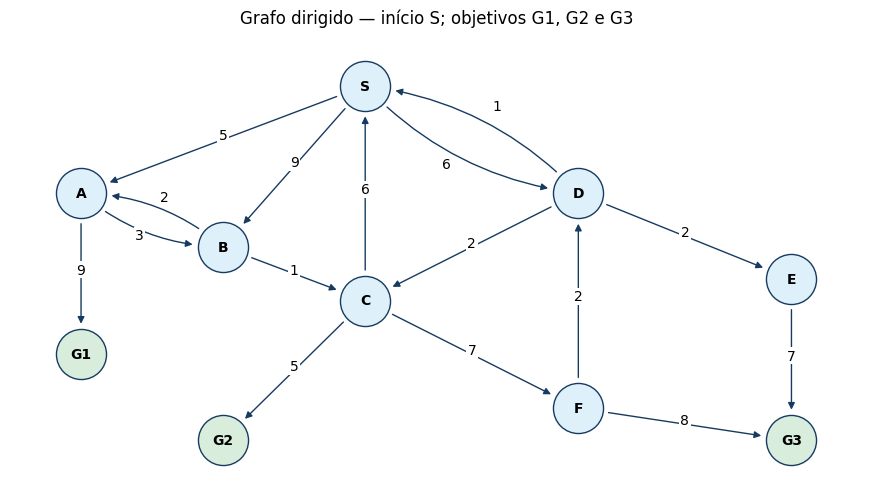


BFS — ordem de retirada: ['S', 'A', 'B', 'D', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,5


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('A', 5), ('B', 9), ('D', 6)]",['S']
2,Expandir A,"[('B', 9), ('D', 6), ('G1', 14)]","['S', 'A']"
3,Expandir B,"[('D', 6), ('G1', 14), ('C', 10)]","['S', 'A', 'B']"
4,Expandir D,"[('G1', 14), ('C', 10), ('E', 8)]","['S', 'A', 'B', 'D']"
5,Retirar G1: objetivo,"[('C', 10), ('E', 8)]","['S', 'A', 'B', 'D', 'G1']"


,De,Para,Decisão
0,A,B,"Ignorar: já em OPEN, sem atualização"
1,B,A,Ignorar: VISITED
2,D,C,"Ignorar: já em OPEN, sem atualização"
3,D,S,Ignorar: VISITED


,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,BFS,G1,[14],5,4,3


In [2]:
ALGORITMO = "BFS"  # ALTERAR: "BFS", "DFS", "UCS"
grafo = criar_grafo()
desenhar(grafo)
r1 = comparar("1", grafo, algoritmos=(ALGORITMO,), detalhes=True, parametros=ALGORITMO)

**Resposta 1:**

| Algoritmo | Objetivo | Caminho | Custo | Profundidade |
|---|---|---|---|---|
| BFS | … | … | … | … |
| DFS | … | … | … | … |
| UCS | … | … | … | … |

Exemplos de OPEN/VISITED e explicação: …

## Experiência 2 — Mudar a ordem dos sucessores
Altere `ORDEM`: **"alfabetica" e "inversa"**. Os custos são os originais. O programa compara BFS e DFS.

Na DFS, a ordem indicada é a ordem pretendida de exploração dos sucessores elegíveis; o código empilha-os pela ordem contrária. Estados já presentes em OPEN não são reposicionados.

**Questão 2.** Que objetivos, caminhos e ordens de retirada mudaram? As garantias de BFS dependem da ordem dos sucessores? Distinga menor profundidade de menor custo. Explique como a pilha produz a ordem de exploração observada.

In [3]:
ORDEM = "alfabetica"  # ALTERAR: "alfabetica", "inversa"
r2 = comparar("2", criar_grafo(), algoritmos=("BFS","DFS"), ordem=ORDEM,
              detalhes=True, parametros=ORDEM)


BFS — ordem de retirada: ['S', 'A', 'B', 'D', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,5


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('A', 5), ('B', 9), ('D', 6)]",['S']
2,Expandir A,"[('B', 9), ('D', 6), ('G1', 14)]","['S', 'A']"
3,Expandir B,"[('D', 6), ('G1', 14), ('C', 10)]","['S', 'A', 'B']"
4,Expandir D,"[('G1', 14), ('C', 10), ('E', 8)]","['S', 'A', 'B', 'D']"
5,Retirar G1: objetivo,"[('C', 10), ('E', 8)]","['S', 'A', 'B', 'D', 'G1']"


,De,Para,Decisão
0,A,B,"Ignorar: já em OPEN, sem atualização"
1,B,A,Ignorar: VISITED
2,D,C,"Ignorar: já em OPEN, sem atualização"
3,D,S,Ignorar: VISITED



DFS — ordem de retirada: ['S', 'A', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,3


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('A', 5), ('B', 9), ('D', 6)]",['S']
2,Expandir A,"[('G1', 14), ('B', 9), ('D', 6)]","['S', 'A']"
3,Retirar G1: objetivo,"[('B', 9), ('D', 6)]","['S', 'A', 'G1']"


,De,Para,Decisão
0,A,B,"Ignorar: já em OPEN, sem atualização"


,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,BFS,G1,[14],5,4,3
1,DFS,G1,[14],3,2,3


**Resposta 2:**

| Ordem | Algoritmo | Objetivo | Custo | Profundidade |
|---|---|---|---|---|
| alfabética | BFS | … | … | … |
| alfabética | DFS | … | … | … |
| inversa | BFS | … | … | … |
| inversa | DFS | … | … | … |

Interpretação: …

## Experiência 3 — Alterar custos sem alterar ligações
Altere apenas `CUSTO_AG1`: **9, 1 e 30**. As restantes ligações mantêm os seus custos. A pesquisa termina ao retirar o primeiro objetivo.

**Questão 3.** Registe os objetivos e custos dos três algoritmos. Quais usam o custo para decidir? BFS continua a devolver uma solução de profundidade mínima? UCS continua a devolver o objetivo de menor custo? Apoie a resposta nos resultados.

In [4]:
CUSTO_AG1 = 9  # ALTERAR: 9, 1, 30
r3 = comparar("3", criar_grafo(CUSTO_AG1), parametros=f"A-G1={CUSTO_AG1}")


BFS — ordem de retirada: ['S', 'A', 'B', 'D', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,5



DFS — ordem de retirada: ['S', 'A', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,3



UCS — ordem de retirada: ['S', 'A', 'D', 'B', 'C', 'E', 'G2']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G2,S → D → C → G2,13,3,7


,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,BFS,G1,[14],5,4,3
1,DFS,G1,[14],3,2,3
2,UCS,G2,[13],7,6,4


**Resposta 3:**

| Custo A→G1 | BFS: objetivo/custo | DFS: objetivo/custo | UCS: objetivo/custo |
|---|---|---|---|
| 9 | … | … | … |
| 1 | … | … | … |
| 30 | … | … | … |

Interpretação: …

## Experiência 4 — Continuar até aos três objetivos
Altere `TODOS`: **False e True**. Com True, continua-se a mesma pesquisa até retirar os três objetivos, sem reinicializar OPEN ou VISITED. Como os objetivos são terminais, não têm sucessores a expandir.

**Questão 4.** Para cada algoritmo, indique a ordem dos três objetivos, os custos e os caminhos. Qual os retira por custo não decrescente? Compare a profundidade dos caminhos devolvidos por BFS. Por que motivo continuar a pesquisa não é o mesmo que reiniciá-la para cada objetivo?

In [5]:
TODOS = False  # ALTERAR: False e True
r4 = comparar("4", criar_grafo(), todos=TODOS, detalhes=True, parametros=f"todos={TODOS}")


BFS — ordem de retirada: ['S', 'A', 'B', 'D', 'G1']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G1,S → A → G1,14,2,5


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('A', 5), ('B', 9), ('D', 6)]",['S']
2,Expandir A,"[('B', 9), ('D', 6), ('G1', 14)]","['S', 'A']"
3,Expandir B,"[('D', 6), ('G1', 14), ('C', 10)]","['S', 'A', 'B']"
4,Expandir D,"[('G1', 14), ('C', 10), ('E', 8)]","['S', 'A', 'B', 'D']"
5,Retirar G1: objetivo,"[('C', 10), ('E', 8)]","['S', 'A', 'B', 'D', 'G1']"


,De,Para,Decisão
0,A,B,"Ignorar: já em OPEN, sem atualização"
1,B,A,Ignorar: VISITED
2,D,C,"Ignorar: já em OPEN, sem atualização"
3,D,S,Ignorar: VISITED



DFS — ordem de retirada: ['S', 'A', 'G1']


...


UCS — ordem de retirada: ['S', 'A', 'D', 'B', 'C', 'E', 'G2']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G2,S → D → C → G2,13,3,7


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('A', 5), ('D', 6), ('B', 9)]",['S']
2,Expandir A,"[('D', 6), ('B', 8), ('G1', 14)]","['S', 'A']"
3,Expandir D,"[('B', 8), ('C', 8), ('E', 8), ('G1', 14)]","['S', 'A', 'D']"
4,Expandir B,"[('C', 8), ('E', 8), ('G1', 14)]","['S', 'A', 'D', 'B']"
5,Expandir C,"[('E', 8), ('G2', 13), ('G1', 14), ('F', 15)]","['S', 'A', 'D', 'B', 'C']"
6,Expandir E,"[('G2', 13), ('G1', 14), ('F', 15), ('G3', 15)]","['S', 'A', 'D', 'B', 'C', 'E']"
7,Retirar G2: objetivo,"[('G1', 14), ('F', 15), ('G3', 15)]","['S', 'A', 'D', 'B', 'C', 'E', 'G2']"


,De,Para,Decisão
0,A,B,Atualizar: 9 → 8
1,D,S,Ignorar: VISITED
2,B,A,Ignorar: VISITED
3,B,C,"Ignorar: já em OPEN, sem atualização"
4,C,S,Ignorar: VISITED


,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,BFS,G1,[14],5,4,3
1,DFS,G1,[14],3,2,3
2,UCS,G2,[13],7,6,4


**Resposta 4:**

| Algoritmo | Ordem dos objetivos | Custos na mesma ordem |
|---|---|---|
| BFS | … | … |
| DFS | … | … |
| UCS | … | … |

Caminhos, profundidades e interpretação: …

## Experiência 5 — Por que atualizar um estado em OPEN?
Usamos um pequeno grafo dirigido diferente: **S→A (4), S→B (1), B→A (1), A→G (2), B→G (10)**. O único objetivo é G.

Altere `ATUALIZAR_OPEN`: **False e True**. False é uma versão deliberadamente incompleta de UCS que ignora melhorias; True aplica UCS corretamente. Não se trata de reabrir VISITED: as melhorias ocorrem enquanto os estados ainda estão em OPEN.

**Questão 5.** Identifique as melhorias de custo e de pai. Compare o caminho e custo devolvidos. Explique por que a regra «já está em OPEN, ignorar» é insuficiente para UCS e por que devemos testar o objetivo ao retirar, em vez de terminar logo que é descoberto.

In [6]:
ATUALIZAR_OPEN = False  # ALTERAR: False e True
grafo5 = {"S":{"A":4,"B":1},"A":{"G":2},"B":{"A":1,"G":10},"G":{}}
print("UCS correto" if ATUALIZAR_OPEN else "Versão incompleta: ignora melhorias em OPEN")
r5 = comparar("5", grafo5, algoritmos=("UCS",), objetivos=("G",),
              atualizar_open=ATUALIZAR_OPEN, detalhes=True,
              parametros=f"atualizar={ATUALIZAR_OPEN}")

Versão incompleta: ignora melhorias em OPEN

UCS — ordem de retirada: ['S', 'B', 'A', 'G']


,Objetivo,Caminho,Custo,Profundidade,Retirada nº
0,G,S → B → G,11,2,4


,Operação,OPEN (próximo à esquerda),VISITED
0,Inicial,"[('S', 0)]",[]
1,Expandir S,"[('B', 1), ('A', 4)]",['S']
2,Expandir B,"[('A', 4), ('G', 11)]","['S', 'B']"
3,Expandir A,"[('G', 11)]","['S', 'B', 'A']"
4,Retirar G: objetivo,[],"['S', 'B', 'A', 'G']"


,De,Para,Decisão
0,B,A,Ignorar melhoria: 4 → 2
1,A,G,Ignorar melhoria: 11 → 6


,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,UCS,G,[11],4,3,2


**Resposta 5:**

| Atualizar OPEN | Caminho | Custo |
|---|---|---|
| False | … | … |
| True | … | … |

Melhorias observadas e momento do teste do objetivo: …

## Histórico e entrega
Consulte todas as configurações executadas. Complete as cinco respostas e guarde o notebook com os resultados. As execuções guardadas inicialmente mostram apenas os parâmetros iniciais; faltam as restantes experiências pedidas.

In [ ]:
display(pd.DataFrame(historico))

,Experiência,Parâmetros,Algoritmo,Objetivos retirados,Custos,Retiradas,Expansões,Máximo OPEN
0,1,BFS,BFS,G1,[14],5,4,3
1,2,alfabetica,BFS,G1,[14],5,4,3
2,2,alfabetica,DFS,G1,[14],3,2,3
3,3,A-G1=9,BFS,G1,[14],5,4,3
4,3,A-G1=9,DFS,G1,[14],3,2,3
5,3,A-G1=9,UCS,G2,[13],7,6,4
6,4,todos=False,BFS,G1,[14],5,4,3
7,4,todos=False,DFS,G1,[14],3,2,3
8,4,todos=False,UCS,G2,[13],7,6,4
9,5,atualizar=False,UCS,G,[11],4,3,2
